In [3]:
!git clone https://github.com/BHVPhuc/Lab03_AI.git
!git checkout origin feature/fashion
%cd Lab03_AI
!pwd

Cloning into 'Lab03_AI'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 72 (delta 25), reused 60 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 828.69 KiB | 13.58 MiB/s, done.
Resolving deltas: 100% (25/25), done.
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
/kaggle/working/Lab03_AI
/kaggle/working/Lab03_AI


# 📑 Phân loại Fashion-MNIST - AI Project 3

Thành viên thực hiện: **Thành viên B**
Nhiệm vụ: Phân tích tập dữ liệu Fashion-MNIST, huấn luyện và so sánh mô hình **Decision Tree** và **Neural Network (MLP)**.

In [5]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm thư mục cha vào sys.path để import helpers.py
sys.path.append(os.path.abspath('..'))
from utils.helpers import stratified_split, evaluate_model, plot_multiple_distributions

## 2.1 Chuẩn bị dữ liệu (Preparing the dataset)

Tải dữ liệu Fashion-MNIST từ OpenML và thực hiện phân chia tập huấn luyện (Train), kiểm định (Validation) theo tỷ lệ 80/20 phân tầng (stratified), giữ nguyên tập kiểm thử (Test) có sẵn.

In [11]:
import os
from utils.helpers import read_idx_file   # hoặc from helpers import read_idx_file

BASE_PATH = "/kaggle/input/datasets/vnhphcbuhunh/the-fashion-mnist-dataset/data/fashion"

X_train = read_idx_file(os.path.join(BASE_PATH, "train-images-idx3-ubyte"))
y_train = read_idx_file(os.path.join(BASE_PATH, "train-labels-idx1-ubyte"))
X_test  = read_idx_file(os.path.join(BASE_PATH, "t10k-images-idx3-ubyte"))
y_test  = read_idx_file(os.path.join(BASE_PATH, "t10k-labels-idx1-ubyte"))

# Ghép lại thành một bộ duy nhất theo đúng thứ tự (train trước, test sau)
X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])

print("Train images shape:", X_train.shape)
print("Train labels shape:", y_train.shape)
print("Test images shape :", X_test.shape)
print("Test labels shape :", y_test.shape)
print("Full X shape:", X.shape, "Full y shape:", y.shape)

✅ Train images shape: (60000, 784)
✅ Train labels shape: (60000,)
✅ Test images shape : (10000, 784)
✅ Test labels shape : (10000,)
✅ Full X shape: (70000, 784) Full y shape: (70000,)


In [12]:
# Chia tập Train_full (60,000 mẫu đầu) và tập Test (10,000 mẫu cuối)
X_train_full, y_train_full = X[:60000], y[:60000]
X_test, y_test = X[60000:], y[60000:]

# Chia tập Train_full thành Train (80%) và Validation (20%) bằng stratified split
X_train, y_train, X_val, y_val = stratified_split(X_train_full, y_train_full, val_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}, nhãn: {y_train.shape}")
print(f"Kích thước tập Validation: {X_val.shape}, nhãn: {y_val.shape}")
print(f"Kích thước tập Test: {X_test.shape}, nhãn: {y_test.shape}")

Kích thước tập Train: (48000, 784), nhãn: (48000,)
Kích thước tập Validation: (12000, 784), nhãn: (12000,)
Kích thước tập Test: (10000, 784), nhãn: (10000,)


In [13]:
# Khai báo tên các lớp (Class names)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

/kaggle/working/Lab03_AI/utils/helpers.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[i], palette='viridis')
/kaggle/working/Lab03_AI/utils/helpers.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[i], palette='viridis')
/kaggle/working/Lab03_AI/utils/helpers.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[i], palette='viridis')
/kaggle/working/Lab03_AI/utils/helpers.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

Đã lưu biểu đồ tổng hợp vào ./figures/fashion_distribution.png


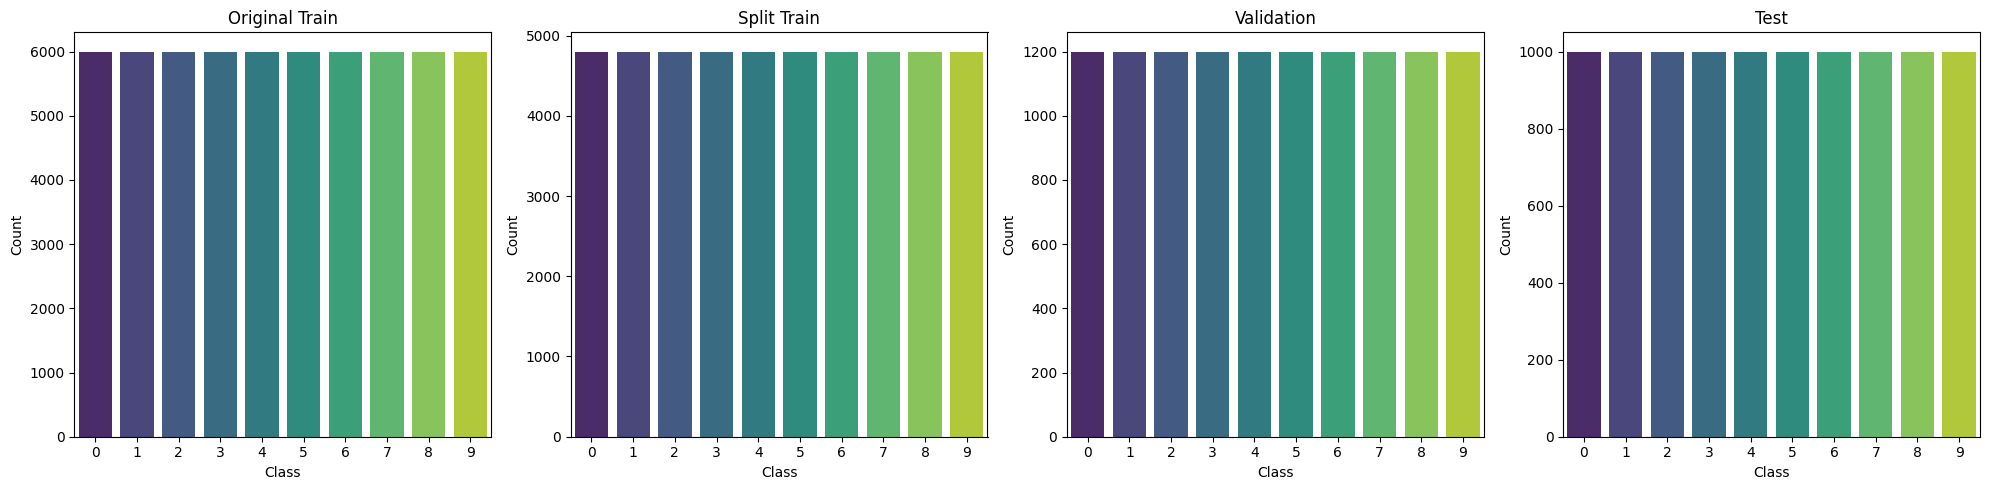

In [14]:
# Vẽ biểu đồ class distribution
os.makedirs('../figures', exist_ok=True)
plot_multiple_distributions(
    [y_train_full, y_train, y_val, y_test],
    ["Original Train", "Split Train", "Validation", "Test"],
    save_path="./figures/fashion_distribution.png"
)

## 2.2 Xây dựng cây quyết định (Building the decision tree classifier)

Fit mô hình `DecisionTreeClassifier` (sử dụng Entropy) trên tập Train và trực quan hóa cây bằng Graphviz.

In [22]:
from sklearn.tree import DecisionTreeClassifier
import graphviz
from sklearn.tree import export_graphviz

print("Đang huấn luyện mô hình Decision Tree mặc định...")
dt_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_base.fit(X_train, y_train)
print(f"Độ chính xác trên Validation set (Mô hình mặc định): {dt_base.score(X_val, y_val):.4f}")

Đang huấn luyện mô hình Decision Tree mặc định...
Độ chính xác trên Validation set (Mô hình mặc định): 0.8073


Đang sinh sơ đồ cây quyết định (giới hạn độ sâu tối đa = 3 để dễ quan sát)...
Đã lưu sơ đồ cây quyết định vào figures/fashion_tree.png


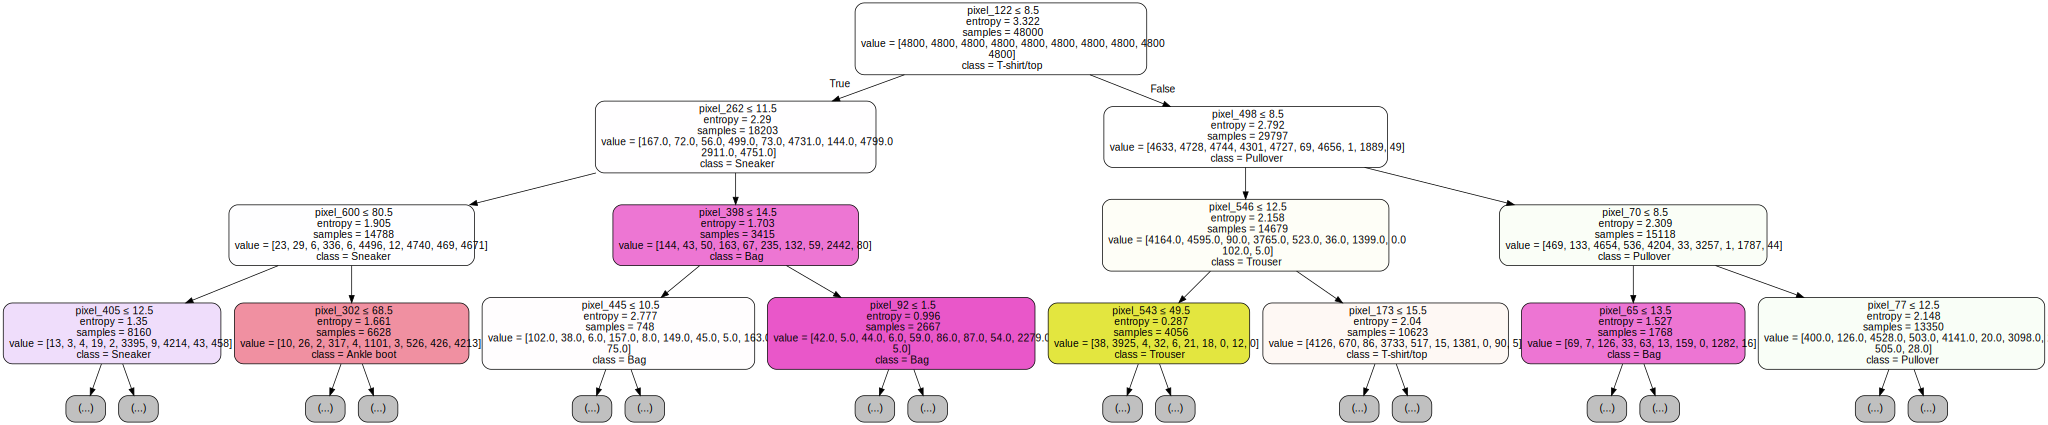

In [23]:
print("Đang sinh sơ đồ cây quyết định (giới hạn độ sâu tối đa = 3 để dễ quan sát)...")
dot_data = export_graphviz(
    dt_base, 
    max_depth=3,
    feature_names=[f"pixel_{i}" for i in range(X_train.shape[1])],
    class_names=class_names,
    filled=True, 
    rounded=True,  
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("./figures/fashion_tree", format="png", cleanup=True)
print("Đã lưu sơ đồ cây quyết định vào figures/fashion_tree.png")
graph

## 2.3 Tinh chỉnh siêu tham số (Hyperparameter tuning for decision tree classifier)

Tìm cấu hình tốt nhất cho các siêu tham số `max_depth`, `min_samples_split`, và `min_samples_leaf` bằng cách đánh giá trên tập Validation.

In [24]:
from sklearn.model_selection import ParameterGrid

# Thiết lập danh sách các siêu tham số cần tinh chỉnh
param_grid = {
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_val_acc = 0.0
best_params = {}
best_dt_model = None

print("Bắt đầu quá trình Tinh chỉnh Siêu tham số (Grid Search)...")
for params in ParameterGrid(param_grid):
    dt = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42
    )
    dt.fit(X_train, y_train)
    val_acc = dt.score(X_val, y_val)
    print(f"Params: {params} | Validation Accuracy: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_dt_model = dt

print("\n--- KẾT QUẢ TỐT NHẤT DỰA TRÊN TẬP VALIDATION ---")
print("Best Hyperparameters:", best_params)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Bắt đầu quá trình Tinh chỉnh Siêu tham số (Grid Search)...
Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2} | Validation Accuracy: 0.8084
Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5} | Validation Accuracy: 0.8071
Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10} | Validation Accuracy: 0.8086
Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2} | Validation Accuracy: 0.8076
Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5} | Validation Accuracy: 0.8071
Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10} | Validation Accuracy: 0.8081
Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2} | Validation Accuracy: 0.8084
Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5} | Validation Accuracy: 0.8084
Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10} | Validation Accuracy: 0.8083
Params: {'m

## 2.4 Xây dựng bộ phân lớp mạng nơ-ron (Building the neural network classifier)

Huấn luyện mô hình `MLPClassifier` với ít nhất một ẩn lớp (hidden layer) và hàm kích hoạt phi tuyến, đánh giá hiệu năng trên tập Validation.

In [25]:
from sklearn.neural_network import MLPClassifier

print("Đang huấn luyện mô hình Mạng Nơ-ron (MLP)...")
# Thiết lập mạng MLP: 1 hidden layer gồm 128 nơ-ron, hàm kích hoạt relu, solver adam
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    verbose=True
)

mlp.fit(X_train, y_train)
mlp_val_acc = mlp.score(X_val, y_val)
print(f"Độ chính xác của MLP trên Validation set: {mlp_val_acc:.4f}")

Đang huấn luyện mô hình Mạng Nơ-ron (MLP)...
Iteration 1, loss = 5.89779697
Iteration 2, loss = 2.62092486
Iteration 3, loss = 1.12268895
Iteration 4, loss = 0.76252077
Iteration 5, loss = 0.62846044
Iteration 6, loss = 0.55811984
Iteration 7, loss = 0.50854626
Iteration 8, loss = 0.47666708
Iteration 9, loss = 0.44356158
Iteration 10, loss = 0.42806769
Iteration 11, loss = 0.41306424
Iteration 12, loss = 0.40214415
Iteration 13, loss = 0.39061019
Iteration 14, loss = 0.39039433
Iteration 15, loss = 0.37333894
Iteration 16, loss = 0.36160014
Iteration 17, loss = 0.36599767
Iteration 18, loss = 0.35900139
Iteration 19, loss = 0.35290296
Iteration 20, loss = 0.34734443
Iteration 21, loss = 0.34673324
Iteration 22, loss = 0.35098802
Iteration 23, loss = 0.34311530
Iteration 24, loss = 0.34411801
Iteration 25, loss = 0.34415433
Iteration 26, loss = 0.33079105
Iteration 27, loss = 0.33160806
Iteration 28, loss = 0.33341664
Iteration 29, loss = 0.32769098
Iteration 30, loss = 0.32956554
Iter

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


## 2.5 Đánh giá và so sánh hiệu năng (Performance evaluation and comparison)

Đánh giá các mô hình tối ưu đã chọn trên tập dữ liệu kiểm thử độc lập (Test Set), tính toán `classification_report` và vẽ `confusion_matrix`.

=== ĐÁNH GIÁ MÔ HÌNH DECISION TREE (TUNED) TRÊN TEST SET ===

📊 KẾT QUẢ ĐÁNH GIÁ - Decision Tree (Tuned)
Độ chính xác (Accuracy): 0.8071

📋 Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.76      0.76      1000
     Trouser       0.95      0.94      0.94      1000
    Pullover       0.68      0.71      0.69      1000
       Dress       0.82      0.80      0.81      1000
        Coat       0.68      0.70      0.69      1000
      Sandal       0.91      0.90      0.91      1000
       Shirt       0.56      0.53      0.54      1000
     Sneaker       0.87      0.91      0.89      1000
         Bag       0.93      0.93      0.93      1000
  Ankle boot       0.92      0.90      0.91      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

Đã lưu confusion matrix vào ../figures/fashion_dt_cm.png


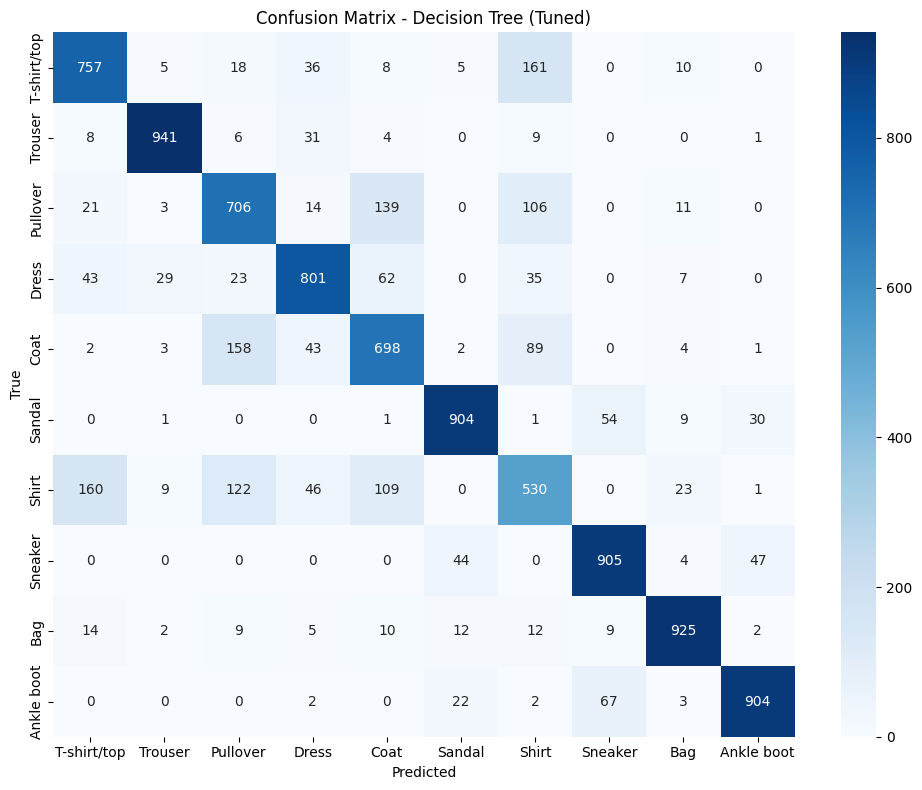

In [26]:
print("=== ĐÁNH GIÁ MÔ HÌNH DECISION TREE (TUNED) TRÊN TEST SET ===")
y_pred_dt, dt_test_acc = evaluate_model(
    best_dt_model, 
    X_test, 
    y_test, 
    model_name="Decision Tree (Tuned)", 
    save_cm_path="../figures/fashion_dt_cm.png",
    class_names=class_names
)

=== ĐÁNH GIÁ MÔ HÌNH NEURAL NETWORK (MLP) TRÊN TEST SET ===

📊 KẾT QUẢ ĐÁNH GIÁ - Neural Network (MLP)
Độ chính xác (Accuracy): 0.8520

📋 Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.66      0.76      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.81      0.67      0.74      1000
       Dress       0.83      0.89      0.86      1000
        Coat       0.73      0.79      0.76      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.57      0.71      0.63      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.95      0.97      0.96      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000

Đã lưu confusion matrix vào ../figures/fashion_mlp_cm.png


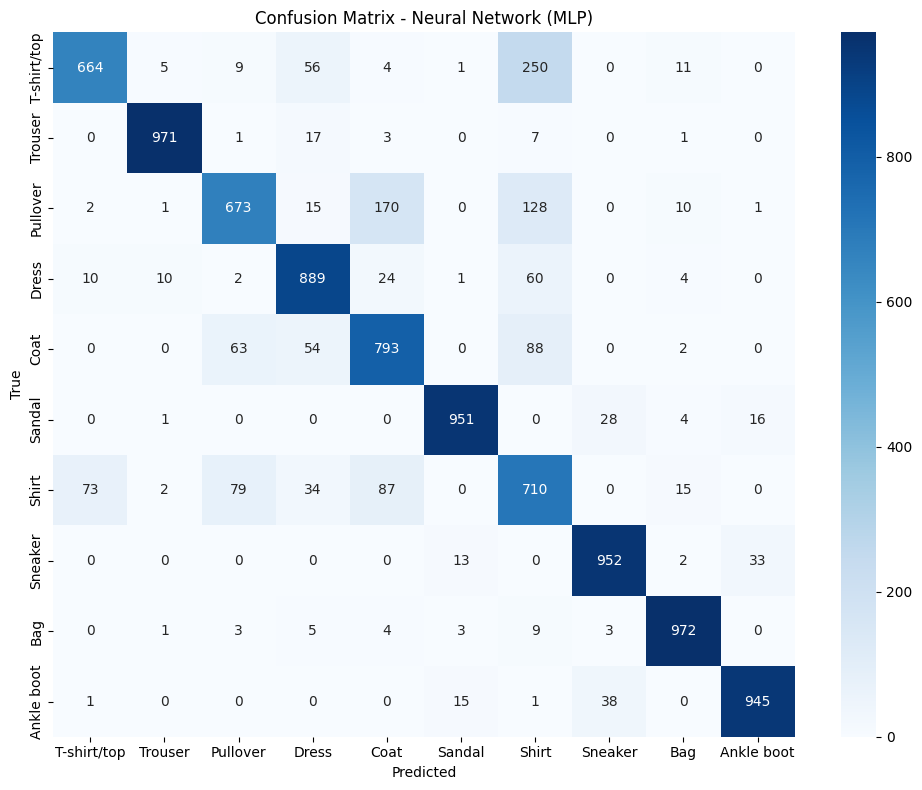

In [27]:
print("=== ĐÁNH GIÁ MÔ HÌNH NEURAL NETWORK (MLP) TRÊN TEST SET ===")
y_pred_mlp, mlp_test_acc = evaluate_model(
    mlp, 
    X_test, 
    y_test, 
    model_name="Neural Network (MLP)", 
    save_cm_path="../figures/fashion_mlp_cm.png",
    class_names=class_names
)

## Nhận xét và Kết luận (Insights & Conclusion)

1. **Độ chính xác (Accuracy):** Mạng nơ-ron MLP mang lại kết quả tốt hơn rõ rệt so với Decision Tree trên tập dữ liệu hình ảnh thời trang Fashion-MNIST. Điều này phản ánh khả năng vượt trội của MLP trong việc tự động trích xuất các đặc trưng phân tầng phức tạp.
2. **Ma trận nhầm lẫn (Confusion Matrix):** Các lỗi chủ yếu tập trung vào các lớp trang phục có hình dáng tương tự nhau như **Shirt** (hay bị nhầm với T-shirt/top, Coat và Pullover). Việc phân biệt các chi tiết như khuy áo, cổ áo đòi hỏi khả năng học phi tuyến sâu sắc mà Decision Tree khó đáp ứng được khi bị khống chế độ sâu cây.
3. **Độ phức tạp:** Decision Tree học nhanh và trực quan trực tiếp cấu trúc cây ra được, tuy nhiên dễ bị quá khớp (overfit) và có hiệu suất hạn chế trên dữ liệu ảnh số lớn. MLP cho hiệu năng cao hơn nhưng tốn nhiều thời gian huấn luyện và cấu trúc mô hình có độ minh bạch thấp (Black-box).